In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class CandlestickIndicators:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

        # price series
        self.open = self.df['Open']
        self.close = self.df['Close']
        self.high = self.df['High']
        self.low = self.df['Low']

        # candle components
        self.body = (self.close - self.open).abs()

        self.upper_shadow = (
            self.high - pd.concat([self.open, self.close], axis=1).max(axis=1)
        )

        self.lower_shadow = (
            pd.concat([self.open, self.close], axis=1).min(axis=1) - self.low
        )

        # direction
        self.is_bull = self.close > self.open
        self.is_bear = self.close < self.open

        # RSI & MACD
        self.rsi = self.compute_rsi()
        self.macd, self.macd_signal, self.macd_hist = self.compute_macd()
        
    # trend
    def downtrend(self, n=5):
        return self.close < self.close.rolling(n).mean()
        
    def uptrend(self, n=5):
        return self.close > self.close.rolling(n).mean()

    # RSI
    def compute_rsi(self, period=14):

        delta = self.close.diff()

        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)

        avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))

        return rsi

    # MACD
    def compute_macd(self, fast=12, slow=26, signal=9):

        ema_fast = self.close.ewm(span=fast, adjust=False).mean()
        ema_slow = self.close.ewm(span=slow, adjust=False).mean()

        macd = ema_fast - ema_slow
        macd_signal = macd.ewm(span=signal, adjust=False).mean()
        macd_hist = macd - macd_signal

        return macd, macd_signal, macd_hist

In [4]:
class CandlestickPatterns(CandlestickIndicators):

    # -------- single candle --------
    def hammer(self, trend_n=5):
        return (
            (self.lower_shadow >= 2 * self.body) &
            (self.upper_shadow <= 0.3 * self.body) &
            self.downtrend(trend_n)
        ).fillna(0).astype(int)


    def hanging_man(self, trend_n=5):
        shape = (
            (self.lower_shadow >= 2 * self.body) &
            (self.upper_shadow <= 0.3 * self.body) &
            self.uptrend(trend_n)
        )
        
        return (shape).fillna(0).astype(int)* -1

        
    def shooting_star(self, trend_n=5):
        shape = (
            (self.upper_shadow >= 2 * self.body) &
            (self.lower_shadow <= 0.3 * self.body)
        )
    
        return (
            shape &
            self.uptrend(trend_n)
        ).fillna(0).astype(int)* -1


    def inverted_hammer(self, trend_n=5):
    
        shape = (
            (self.upper_shadow >= 2 * self.body) &
            (self.lower_shadow <= 0.3 * self.body)
        )
    
        pattern = (
            shape &
            self.downtrend(trend_n)
        )
    
    
        return (pattern).fillna(0).astype(int)


    # -------- two candle --------
    def bearish_engulfing(self, trend_n=5):
        pattern = (
            self.uptrend(trend_n).shift(1) &
            self.is_bear &
            self.is_bull.shift(1) &
            (self.open >= self.close.shift(1)) &
            (self.close <= self.open.shift(1))
        )
    
        confirmation = (
            self.close.shift(-1) <
            pd.concat([self.open, self.close], axis=1).min(axis=1)
        )
    
        return (pattern & confirmation).shift(1).fillna(0).astype(int)* -1


    def bullish_engulfing(self, trend_n=5):
        shape = (
            self.downtrend(trend_n).shift(1) &
            self.is_bull &
            self.is_bear.shift(1) &
            (self.open <= self.close.shift(1)) &
            (self.close >= self.open.shift(1))
        )
         
        confirmation = (
            self.close.shift(-1) >
            pd.concat([self.open, self.close], axis=1).max(axis=1)
        )

        return (shape & confirmation).shift(1).fillna(0).astype(int)



    def piercing_pattern(self):
        prev_mid = (self.open.shift(1) + self.close.shift(1)) / 2
        return (
            self.is_bull &
            self.is_bear.shift(1) &
            (self.open < self.low.shift(1)) &
            (self.close > prev_mid)
        ).fillna(0).astype(int)

    def dark_cloud_cover(self):
        prev_mid = (self.open.shift(1) + self.close.shift(1)) / 2
        return (
            self.is_bear &
            self.is_bull.shift(1) &
            (self.open > self.high.shift(1)) &
            (self.close < prev_mid)
        ).fillna(0).astype(int)* -1

    # -------- three candle --------
    def morning_star(self, trend_n=5):
        pattern = (
            self.downtrend(trend_n).shift(2) &                     
            self.is_bear.shift(2) &                       
            (self.body.shift(1) < 0.5 * self.body.shift(2)) &  
            self.is_bull &                               
            (self.close > (self.open.shift(2) + self.close.shift(2)) / 2)
        )
    
        confirmation = (
            self.close.shift(-1) >
            pd.concat([self.open, self.close], axis=1).max(axis=1)
        )
   
    
        return (pattern & confirmation).shift(1).fillna(0).astype(int)


    def evening_star(self, trend_n=5):

        pattern = (
            self.uptrend(trend_n).shift(2) &                     
            self.is_bull.shift(2) &                       
            (self.body.shift(1) < 0.5 * self.body.shift(2)) &  
            self.is_bear &                               
            (self.close < (self.open.shift(2) + self.close.shift(2)) / 2)
        )
    
        confirmation = (
            self.close.shift(-1) <
            pd.concat([self.open, self.close], axis=1).min(axis=1)
        )
  
        return (pattern & confirmation).shift(1).fillna(0).astype(int)* -1
        

    # -------- continuous pattern --------
    def rising_three_methods(
        self,
        n_small=3,
        body_multiplier=1.2,
        inside_tol=0.01,
        strong_close_ratio=0,
        trend_n=5
    ):
    
        total_window = n_small + 2 
        first_idx = total_window - 1
    
        avg_body = self.body.rolling(20).mean()
    
        first_long_bull = (
            self.is_bull.shift(first_idx) &
            (self.body.shift(first_idx) >
             body_multiplier * avg_body.shift(first_idx))
        )
    
        inside_range = True
        for i in range(1, n_small + 1):
    
            inside_range &= (
                (self.high.shift(first_idx - i) <=
                 self.high.shift(first_idx) * (1 + inside_tol)) &
                (self.low.shift(first_idx - i) >=
                 self.low.shift(first_idx) * (1 - inside_tol))
            )
    
        final_strong_bull = (
            self.is_bull &
            (
                self.close >
                self.close.shift(first_idx) +
                strong_close_ratio * self.body.shift(first_idx)
            )
        )
    
        trend_filter = self.uptrend(trend_n).shift(first_idx)
    
        pattern = (
            trend_filter &
            first_long_bull &
            inside_range &
            final_strong_bull
        )
    
        return pattern.astype(int)


    def falling_three_methods(
        self,
        n_small=3,
        body_multiplier=1.2,
        inside_tol=0.01,
        strong_close_ratio=0,
        trend_n=5
    ):

        first_long_black = (
            self.is_bear.shift(n_small + 1) &
            (self.body.shift(n_small + 1) >
             body_multiplier * self.body.rolling(20).mean().shift(n_small + 1))
        )
    
        inside_range = True
        for i in range(1, n_small + 1):
            inside_range &= (
                self.high.shift(i) <=
                self.high.shift(n_small + 1) * (1 + inside_tol)
            ) & (
                self.low.shift(i) >=
                self.low.shift(n_small + 1) * (1 - inside_tol)
            )
    
        final_strong_black = (
            self.is_bear &
            (
                self.close <
                self.close.shift(n_small + 1)
                - strong_close_ratio * self.body.shift(n_small + 1)
            )
        )
    
        pattern = (
            self.downtrend(trend_n).shift(n_small + 1) &
            first_long_black &
            inside_range &
            final_strong_black
        )
    
        return pattern.astype(int)* -1

    # RSI signals
    def rsi_oversold(self, threshold=30):
        return (self.rsi < threshold).astype(int)

    def rsi_overbought(self, threshold=70):
        return (self.rsi > threshold).astype(int)* -1

    def rsi_bearish_divergence(self, lookback=20):
    
        price_new_high = self.close == self.close.rolling(lookback).max()
        rsi_not_new_high = self.rsi < self.rsi.rolling(lookback).max()
    
        return (price_new_high & rsi_not_new_high).astype(int)* -1

    def rsi_bullish_divergence(self, lookback=20):

        price_new_low = self.close == self.close.rolling(lookback).min()
        rsi_not_new_low = self.rsi > self.rsi.rolling(lookback).min()
    
        return (price_new_low & rsi_not_new_low).astype(int)

    # MACD signals
    def macd_bullish_cross(self):
        return (
            (self.macd > self.macd_signal) &
            (self.macd.shift(1) <= self.macd_signal.shift(1))
        ).astype(int)

    def macd_bearish_cross(self):
        return (
            (self.macd < self.macd_signal) &
            (self.macd.shift(1) >= self.macd_signal.shift(1))
        ).astype(int)* -1



In [5]:
import pandas as pd

In [10]:
df = pd.read_csv("C:/Users/tian/Desktop/mint/spx_d2020.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna()
df.head()

,Date,Open,High,Low,Close,Volume
0,2020-04-01,2498.08,2522.75,2447.49,2470.50,3.304389e+09
1,2020-04-02,2458.54,2533.22,2455.79,2526.90,3.586106e+09
2,2020-04-03,2514.92,2538.18,2459.96,2488.65,3.381772e+09
3,2020-04-06,2578.28,2676.85,2574.57,2663.68,3.551033e+09
4,2020-04-07,2738.65,2756.89,2657.67,2659.41,3.911511e+09


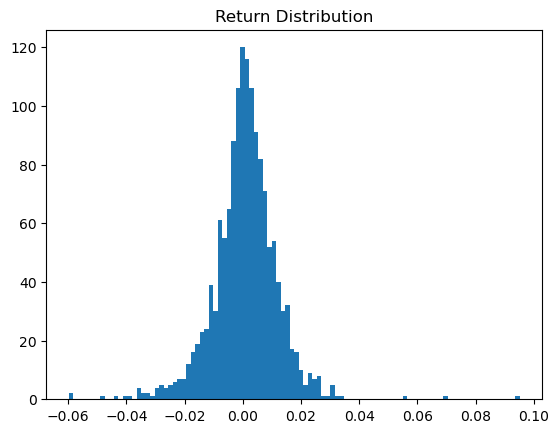

In [12]:
price = df["Close"]
ret = price.pct_change().dropna()
plt.hist(ret, bins=100)
plt.title("Return Distribution")
plt.show()

In [13]:
patterns = CandlestickPatterns(df)

indicator_funcs = {
    "hammer": patterns.hammer,
    "hanging_man": patterns.hanging_man,
    "inverted_hammer": patterns.inverted_hammer,
    "shooting_star": patterns.shooting_star,

    "bullish_engulfing": patterns.bullish_engulfing,
    "bearish_engulfing": patterns.bearish_engulfing,
    "piercing_pattern": patterns.piercing_pattern,
    "dark_cloud_cover": patterns.dark_cloud_cover,

    "morning_star": patterns.morning_star,
    "evening_star": patterns.evening_star,
    
    "rising_three_methods": patterns.rising_three_methods,
    "falling_three_methods": patterns.falling_three_methods,

    "rsi_oversold": patterns.rsi_oversold,
    "rsi_overbought": patterns.rsi_overbought,
    "rsi_bearish_divergence": patterns.rsi_bearish_divergence,
    "rsi_bullish_divergence": patterns.rsi_bullish_divergence,

    "macd_bullish_cross": patterns.macd_bullish_cross,
    "macd_bearish_cross": patterns.macd_bearish_cross

    
}

for name, func in indicator_funcs.items():
    df[name] = func()


In [16]:
df.head(10)

,Date,Open,High,Low,Close,Volume,hammer,hanging_man,inverted_hammer,shooting_star,...,morning_star,evening_star,rising_three_methods,falling_three_methods,rsi_oversold,rsi_overbought,rsi_bearish_divergence,rsi_bullish_divergence,macd_bullish_cross,macd_bearish_cross
0,2020-04-01,2498.08,2522.75,2447.49,2470.50,3.304389e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020-04-02,2458.54,2533.22,2455.79,2526.90,3.586106e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,1,0
2,2020-04-03,2514.92,2538.18,2459.96,2488.65,3.381772e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,0,0
3,2020-04-06,2578.28,2676.85,2574.57,2663.68,3.551033e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,0,0
4,2020-04-07,2738.65,2756.89,2657.67,2659.41,3.911511e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,0,0
5,2020-04-08,2685.00,2760.75,2663.30,2749.98,3.253539e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,0,0
6,2020-04-09,2776.99,2818.57,2762.36,2789.82,4.377856e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,0,0
7,2020-04-13,2782.46,2782.46,2721.17,2761.63,2.930172e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,0,0
8,2020-04-14,2805.10,2851.85,2805.10,2846.06,3.093000e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,0,0
9,2020-04-15,2795.64,2801.88,2761.54,2783.36,2.890772e+09,0,0,0,0,...,0,0,0,0,0,-1,0,0,0,0


In [18]:
all_sums = df.sum(numeric_only=True)
print(all_sums)

Open                      6.888174e+06
High                      6.926715e+06
Low                       6.846985e+06
Close                     6.889496e+06
Volume                    3.824853e+12
hammer                    1.400000e+01
hanging_man              -1.700000e+01
inverted_hammer           1.000000e+01
shooting_star            -3.000000e+00
bullish_engulfing         1.200000e+01
bearish_engulfing        -1.900000e+01
piercing_pattern          2.300000e+01
dark_cloud_cover         -3.500000e+01
morning_star              2.900000e+01
evening_star             -2.300000e+01
rising_three_methods      5.000000e+01
falling_three_methods    -1.400000e+01
rsi_oversold              1.700000e+01
rsi_overbought           -1.320000e+02
rsi_bearish_divergence   -1.740000e+02
rsi_bullish_divergence    3.100000e+01
macd_bullish_cross        6.900000e+01
macd_bearish_cross       -6.900000e+01
dtype: float64


In [20]:
def evaluate_signal(signal, price, horizon=1):

    future_ret = price.pct_change(horizon).shift(-horizon)
    mask = signal != 0

    aligned_signal = signal[mask]
    aligned_ret = future_ret[mask]

    N = len(aligned_ret)

    if N == 0:
        return {
            "N": 0,
            "Directional Accuracy": np.nan,
            "Mean Return": np.nan,
            "Sharpe": np.nan,
            "t-stat": np.nan
        }

    strategy_ret = aligned_signal * aligned_ret

    directional = (strategy_ret > 0).mean()
    mean_ret = strategy_ret.mean()
    std_ret = strategy_ret.std()

    sharpe = mean_ret / std_ret if std_ret != 0 else np.nan

    t_stat = mean_ret / (std_ret / np.sqrt(N)) if std_ret != 0 else np.nan

    return {
        "N": N,
        "Directional Accuracy": directional,
        "Mean Return": mean_ret,
        "Sharpe": sharpe,
        "t-stat": t_stat
    }


In [22]:
results = {}

for name, func in indicator_funcs.items():

    signal = func()

    perf = evaluate_signal(
        signal=signal,
        price=df["Close"],
        horizon=5
    )

    results[name] = perf



In [24]:
horizon = 5   

all_time_series = []

for name, func in indicator_funcs.items():

    signal_raw = func()   # 1 / -1 / 0


    daily_ret = df["Close"].pct_change()

    position = signal_raw.replace(0, np.nan)  
    

    position = position.ffill(limit=horizon-1) 
    
    position = position.fillna(0)

    strategy_ret = position.shift(1) * daily_ret

    temp = pd.DataFrame({
        "Date": df["Date"],
        "Indicator": name,
        "Return": strategy_ret
    })

    all_time_series.append(temp)

time_series_df = pd.concat(all_time_series)
time_series_df = time_series_df.dropna()

time_series_df["Cumulative Return"] = (
    time_series_df
        .groupby("Indicator")["Return"]
        .transform(lambda x: (1 + x).cumprod() - 1)
)

time_series_df.to_csv("momentum_time_series_postcovid.csv", index=False)

print("Time series table saved.")

Time series table saved.


In [26]:
print(time_series_df.groupby("Indicator")["Return"].sum())

Indicator
bearish_engulfing        -0.115673
bullish_engulfing        -0.057339
dark_cloud_cover         -0.306865
evening_star             -0.199497
falling_three_methods    -0.058628
hammer                    0.016556
hanging_man              -0.037465
inverted_hammer           0.191321
macd_bearish_cross       -0.533759
macd_bullish_cross        0.422878
morning_star              0.038223
piercing_pattern         -0.098547
rising_three_methods      0.077403
rsi_bearish_divergence   -0.302542
rsi_bullish_divergence    0.041284
rsi_overbought           -0.209637
rsi_oversold              0.169335
shooting_star            -0.065806
Name: Return, dtype: float64


In [28]:
def newey_west_tstat(x, lag):
    x = np.array(x)
    N = len(x)
    mean_x = np.mean(x)
    x_demean = x - mean_x

    gamma_0 = np.sum(x_demean**2) / N

    var = gamma_0

    for k in range(1, lag+1):
        weight = 1 - k/(lag+1)
        gamma_k = np.sum(x_demean[k:] * x_demean[:-k]) / N
        var += 2 * weight * gamma_k

    se = np.sqrt(var / N)

    return mean_x / se if se != 0 else np.nan

In [30]:
horizons = [1, 3, 5, 7 , 10]
summary_list = []

for name, func in indicator_funcs.items():

    signal = func()

    for h in horizons:

        future_ret = df["Close"].pct_change(h).shift(-h)
        mask = signal != 0

        event_ret = (signal * future_ret)[mask].dropna()

        N = len(event_ret)

        if N > 5:
            mean_ret = event_ret.mean()
            std_ret = event_ret.std()
            sharpe = mean_ret / std_ret if std_ret != 0 else np.nan
            accuracy = (event_ret > 0).mean()
            t_stat = newey_west_tstat(event_ret, lag=h)
            
            summary_list.append({
                "Indicator": name,
                "Horizon": h,
                "Mean_Return": mean_ret,
                "Sharpe": sharpe,
                "Accuracy": accuracy,
                "t_stat_NW": t_stat,
                "N": N
            })

summary_df = pd.DataFrame(summary_list)
summary_df.to_csv("momentum_event_summary_postcovid.csv", index=False)

print("Event summary table saved.")

Event summary table saved.


In [32]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

horizons = [1, 3, 5, 7, 10]
summary_list = []

for name, func in indicator_funcs.items():

    signal = func()

    for h in horizons:

        future_ret = df["Close"].pct_change(h).shift(-h)

        temp = pd.DataFrame({
            "future_ret": future_ret,
            "signal": signal
        }).dropna()

        mask = temp["signal"] != 0
        event_ret = (temp.loc[mask, "signal"] *
                     temp.loc[mask, "future_ret"])

        N = len(event_ret)

        if N > 5:

            mean_ret = event_ret.mean()
            std_ret = event_ret.std()
            sharpe = mean_ret / std_ret if std_ret != 0 else np.nan
            accuracy = (event_ret > 0).mean()

            X = sm.add_constant(temp["signal"])
            y = temp["future_ret"]

            model = sm.OLS(y, X)
            results = model.fit(cov_type="HAC",
                                cov_kwds={"maxlags": h})

            beta = results.params["signal"]
            t_beta = results.tvalues["signal"]
            p_beta = results.pvalues["signal"]
            r2 = results.rsquared

            summary_list.append({
                "Indicator": name,
                "Horizon": h,
                "Mean_Return": mean_ret,
                "Sharpe": sharpe,
                "Accuracy": accuracy,
                "Beta": beta,
                "t_beta_NW": t_beta,
                "p_value": p_beta,
                "R2": r2,
                "N": N
            })

summary_df = pd.DataFrame(summary_list)
summary_df.to_csv("momentum_event_summary_postcovid.csv", index=False)

print("Regression + event summary table saved.")

Regression + event summary table saved.


In [33]:
def backtest(
    price,
    signal,
    cost=0.0005,       
    annualization=252
):

    df = pd.DataFrame(index=price.index)
    df["price"] = price
    df["ret"] = df["price"].pct_change()

    df["position"] = signal.shift(1)

    df["position"] = df["position"].clip(-1, 1)

    df["turnover"] = df["position"].diff().abs()
    df["cost"] = df["turnover"] * cost

    df["strategy_ret"] = df["position"] * df["ret"] - df["cost"]

    df = df.dropna()

    df["equity"] = (1 + df["strategy_ret"]).cumprod()

    ann_return = df["strategy_ret"].mean() * annualization
    ann_vol = df["strategy_ret"].std() * np.sqrt(annualization)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    t_stat = (
        df["strategy_ret"].mean() /
        (df["strategy_ret"].std() / np.sqrt(len(df)))
    )

    rolling_max = df["equity"].cummax()
    drawdown = df["equity"] / rolling_max - 1
    max_dd = drawdown.min()

    results = {
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "t-stat": t_stat,
        "Max Drawdown": max_dd,
        "Total Return": df["equity"].iloc[-1] - 1
    }

    return df, results